**Experiment 4: Binary Classification using Linear and Kernel-Based Models**

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import math


Importing Dataset

In [2]:
df = pd.read_csv("spambase_csv_Kaggle.csv")
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


Pre-Processing Data

In [3]:
df.isnull().sum()

word_freq_make                0
word_freq_address             0
word_freq_all                 0
word_freq_3d                  0
word_freq_our                 0
word_freq_over                0
word_freq_remove              0
word_freq_internet            0
word_freq_order               0
word_freq_mail                0
word_freq_receive             0
word_freq_will                0
word_freq_people              0
word_freq_report              0
word_freq_addresses           0
word_freq_free                0
word_freq_business            0
word_freq_email               0
word_freq_you                 0
word_freq_credit              0
word_freq_your                0
word_freq_font                0
word_freq_000                 0
word_freq_money               0
word_freq_hp                  0
word_freq_hpl                 0
word_freq_george              0
word_freq_650                 0
word_freq_lab                 0
word_freq_labs                0
word_freq_telnet              0
word_fre

In [4]:
X = df.drop(columns = ["class"])
X

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.0,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78


In [5]:
y = df['class']
y

0       1
1       1
2       1
3       1
4       1
       ..
4596    0
4597    0
4598    0
4599    0
4600    0
Name: class, Length: 4601, dtype: int64

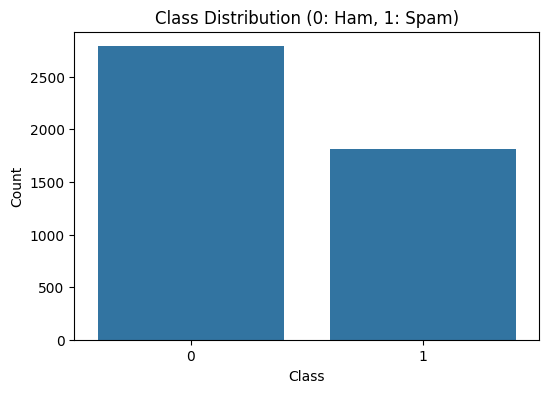

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Class Distribution (0: Ham, 1: Spam)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

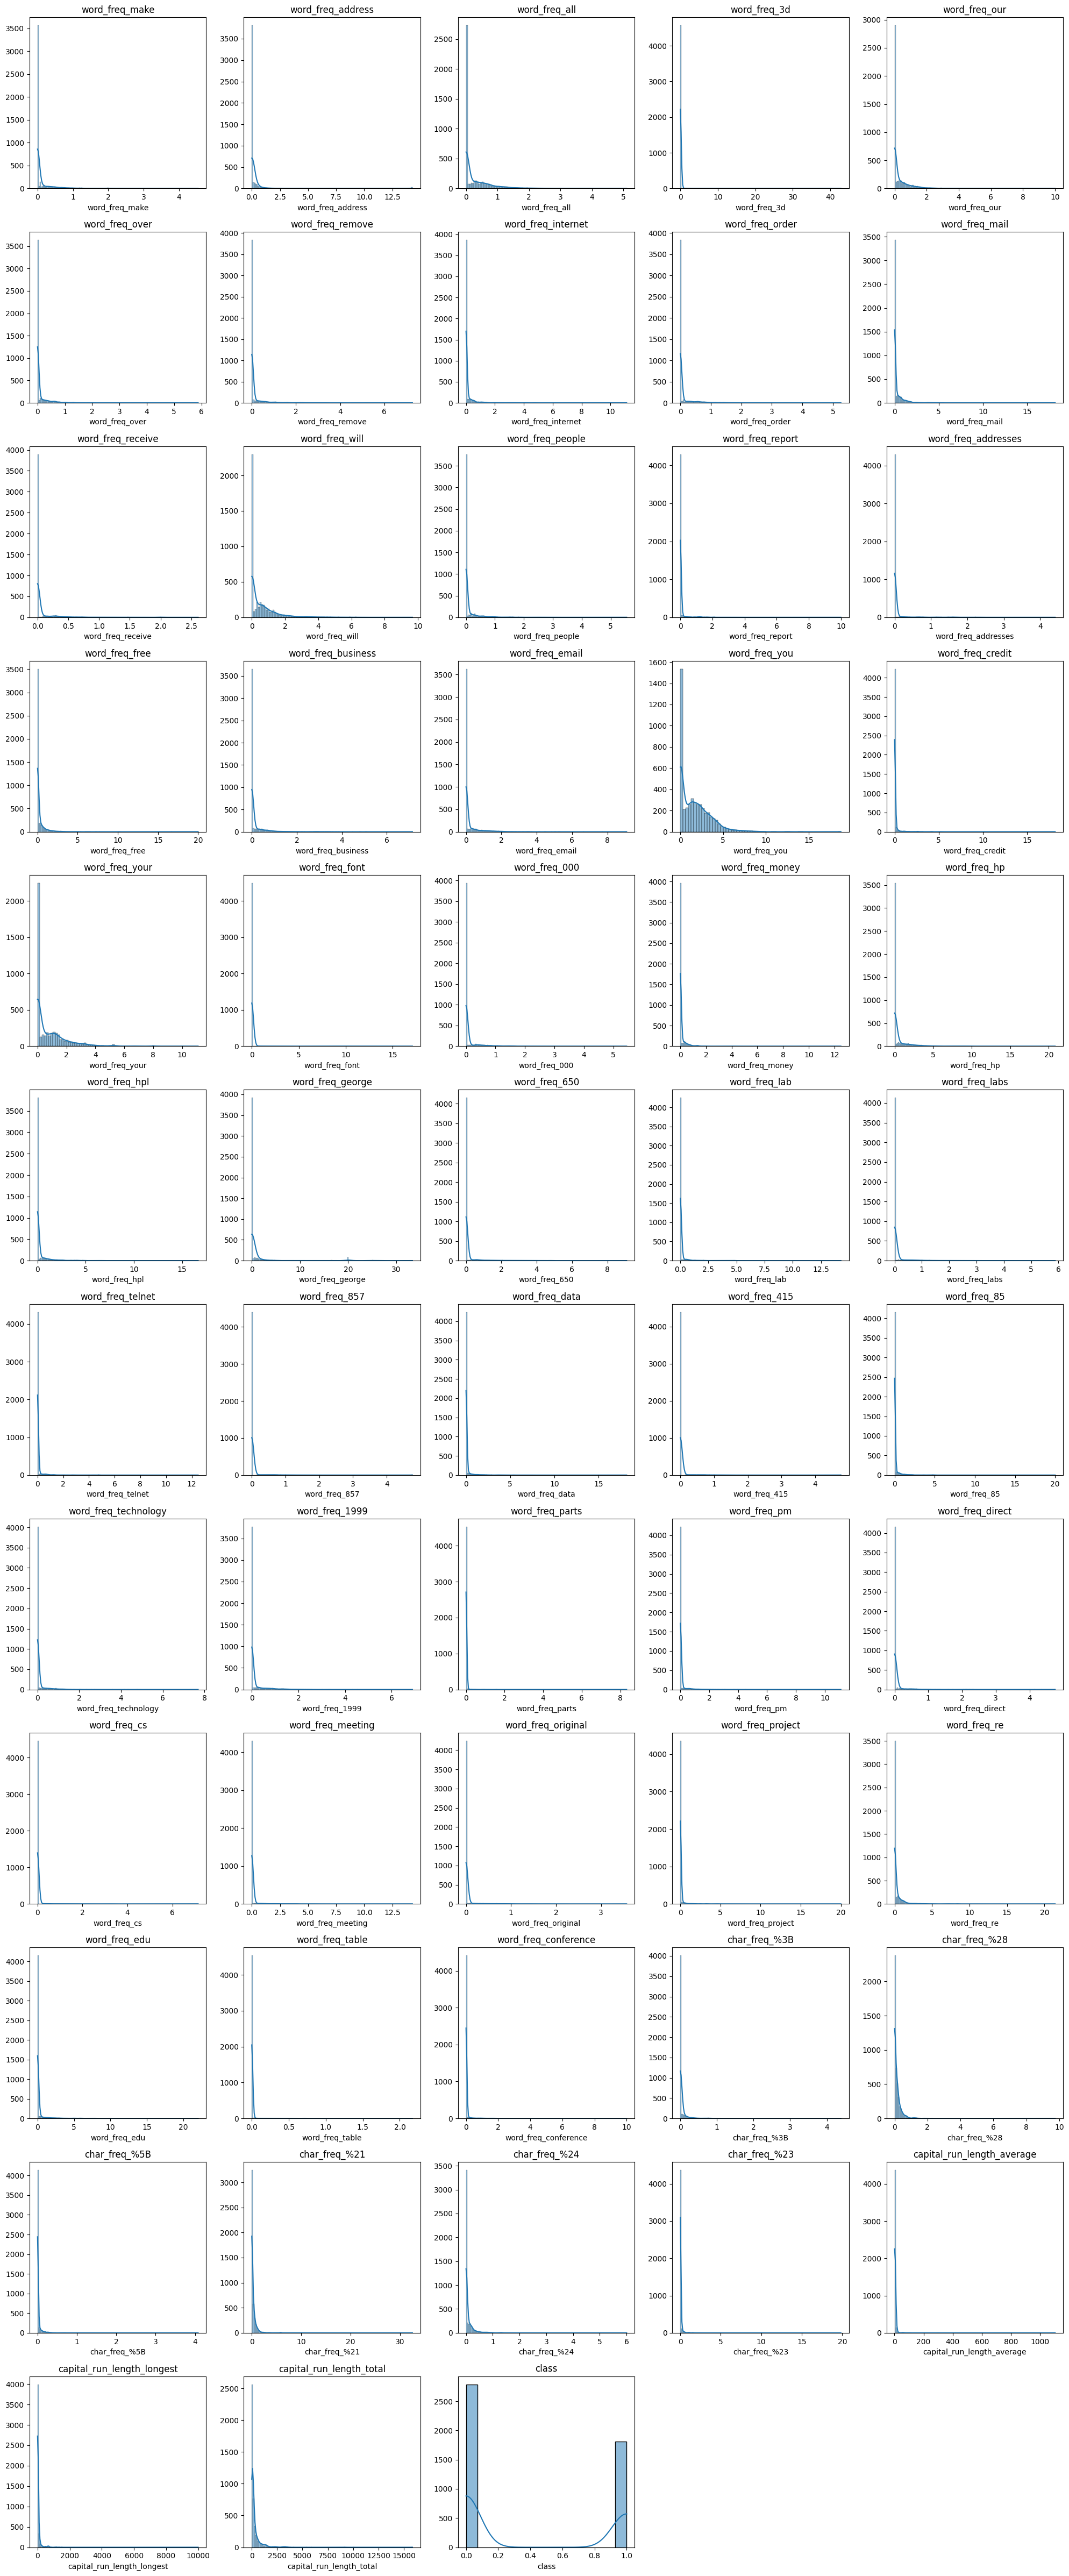

In [7]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
n_cols = 5
n_rows = math.ceil(len(numerical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('')

for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


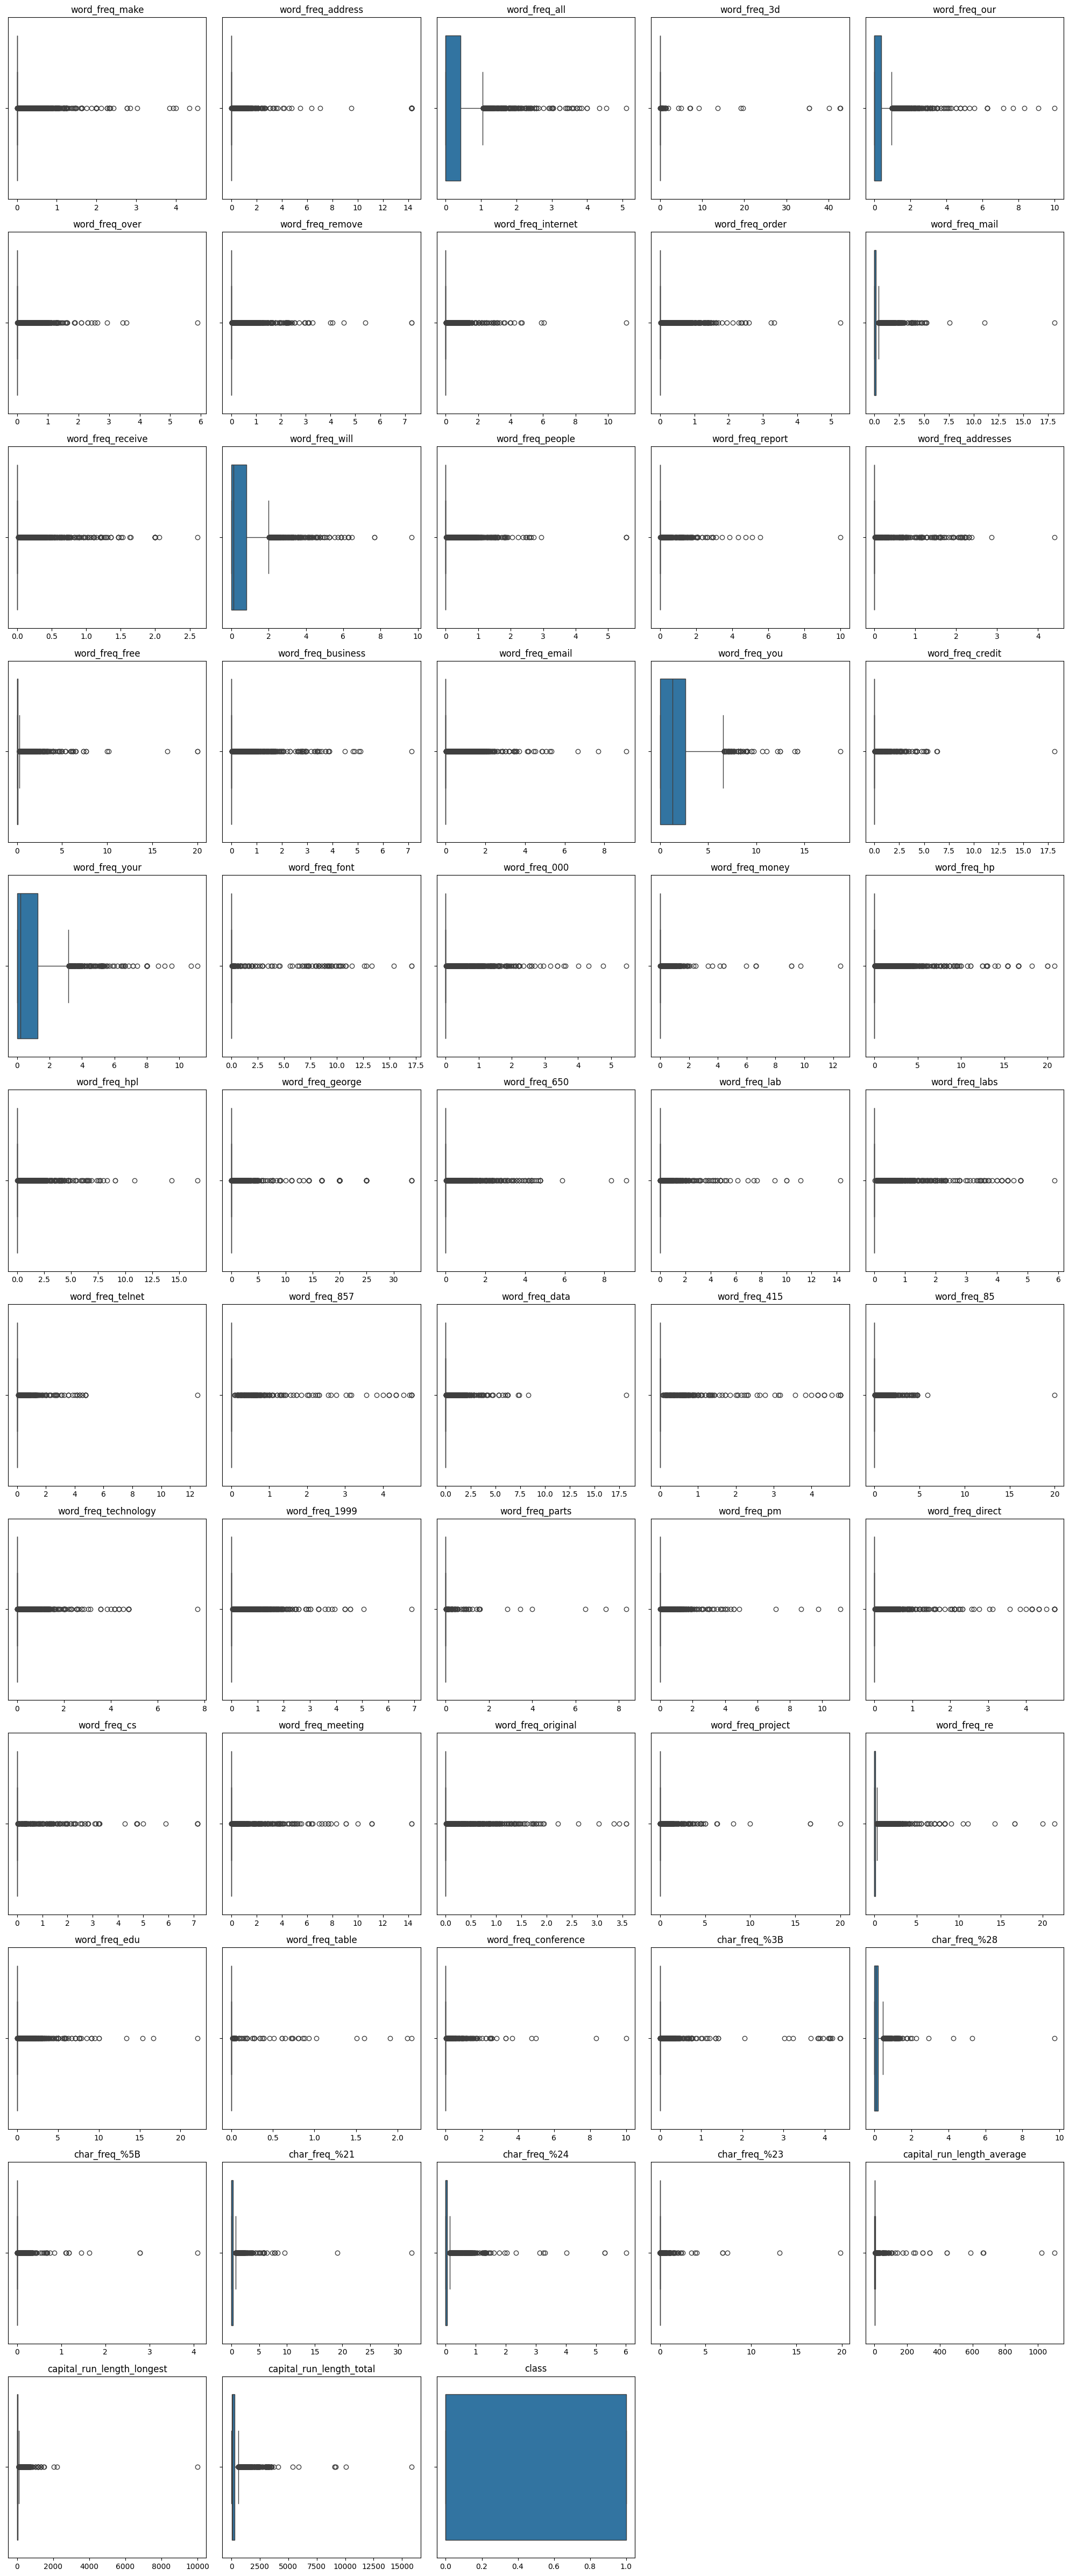

In [8]:

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')

for i in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

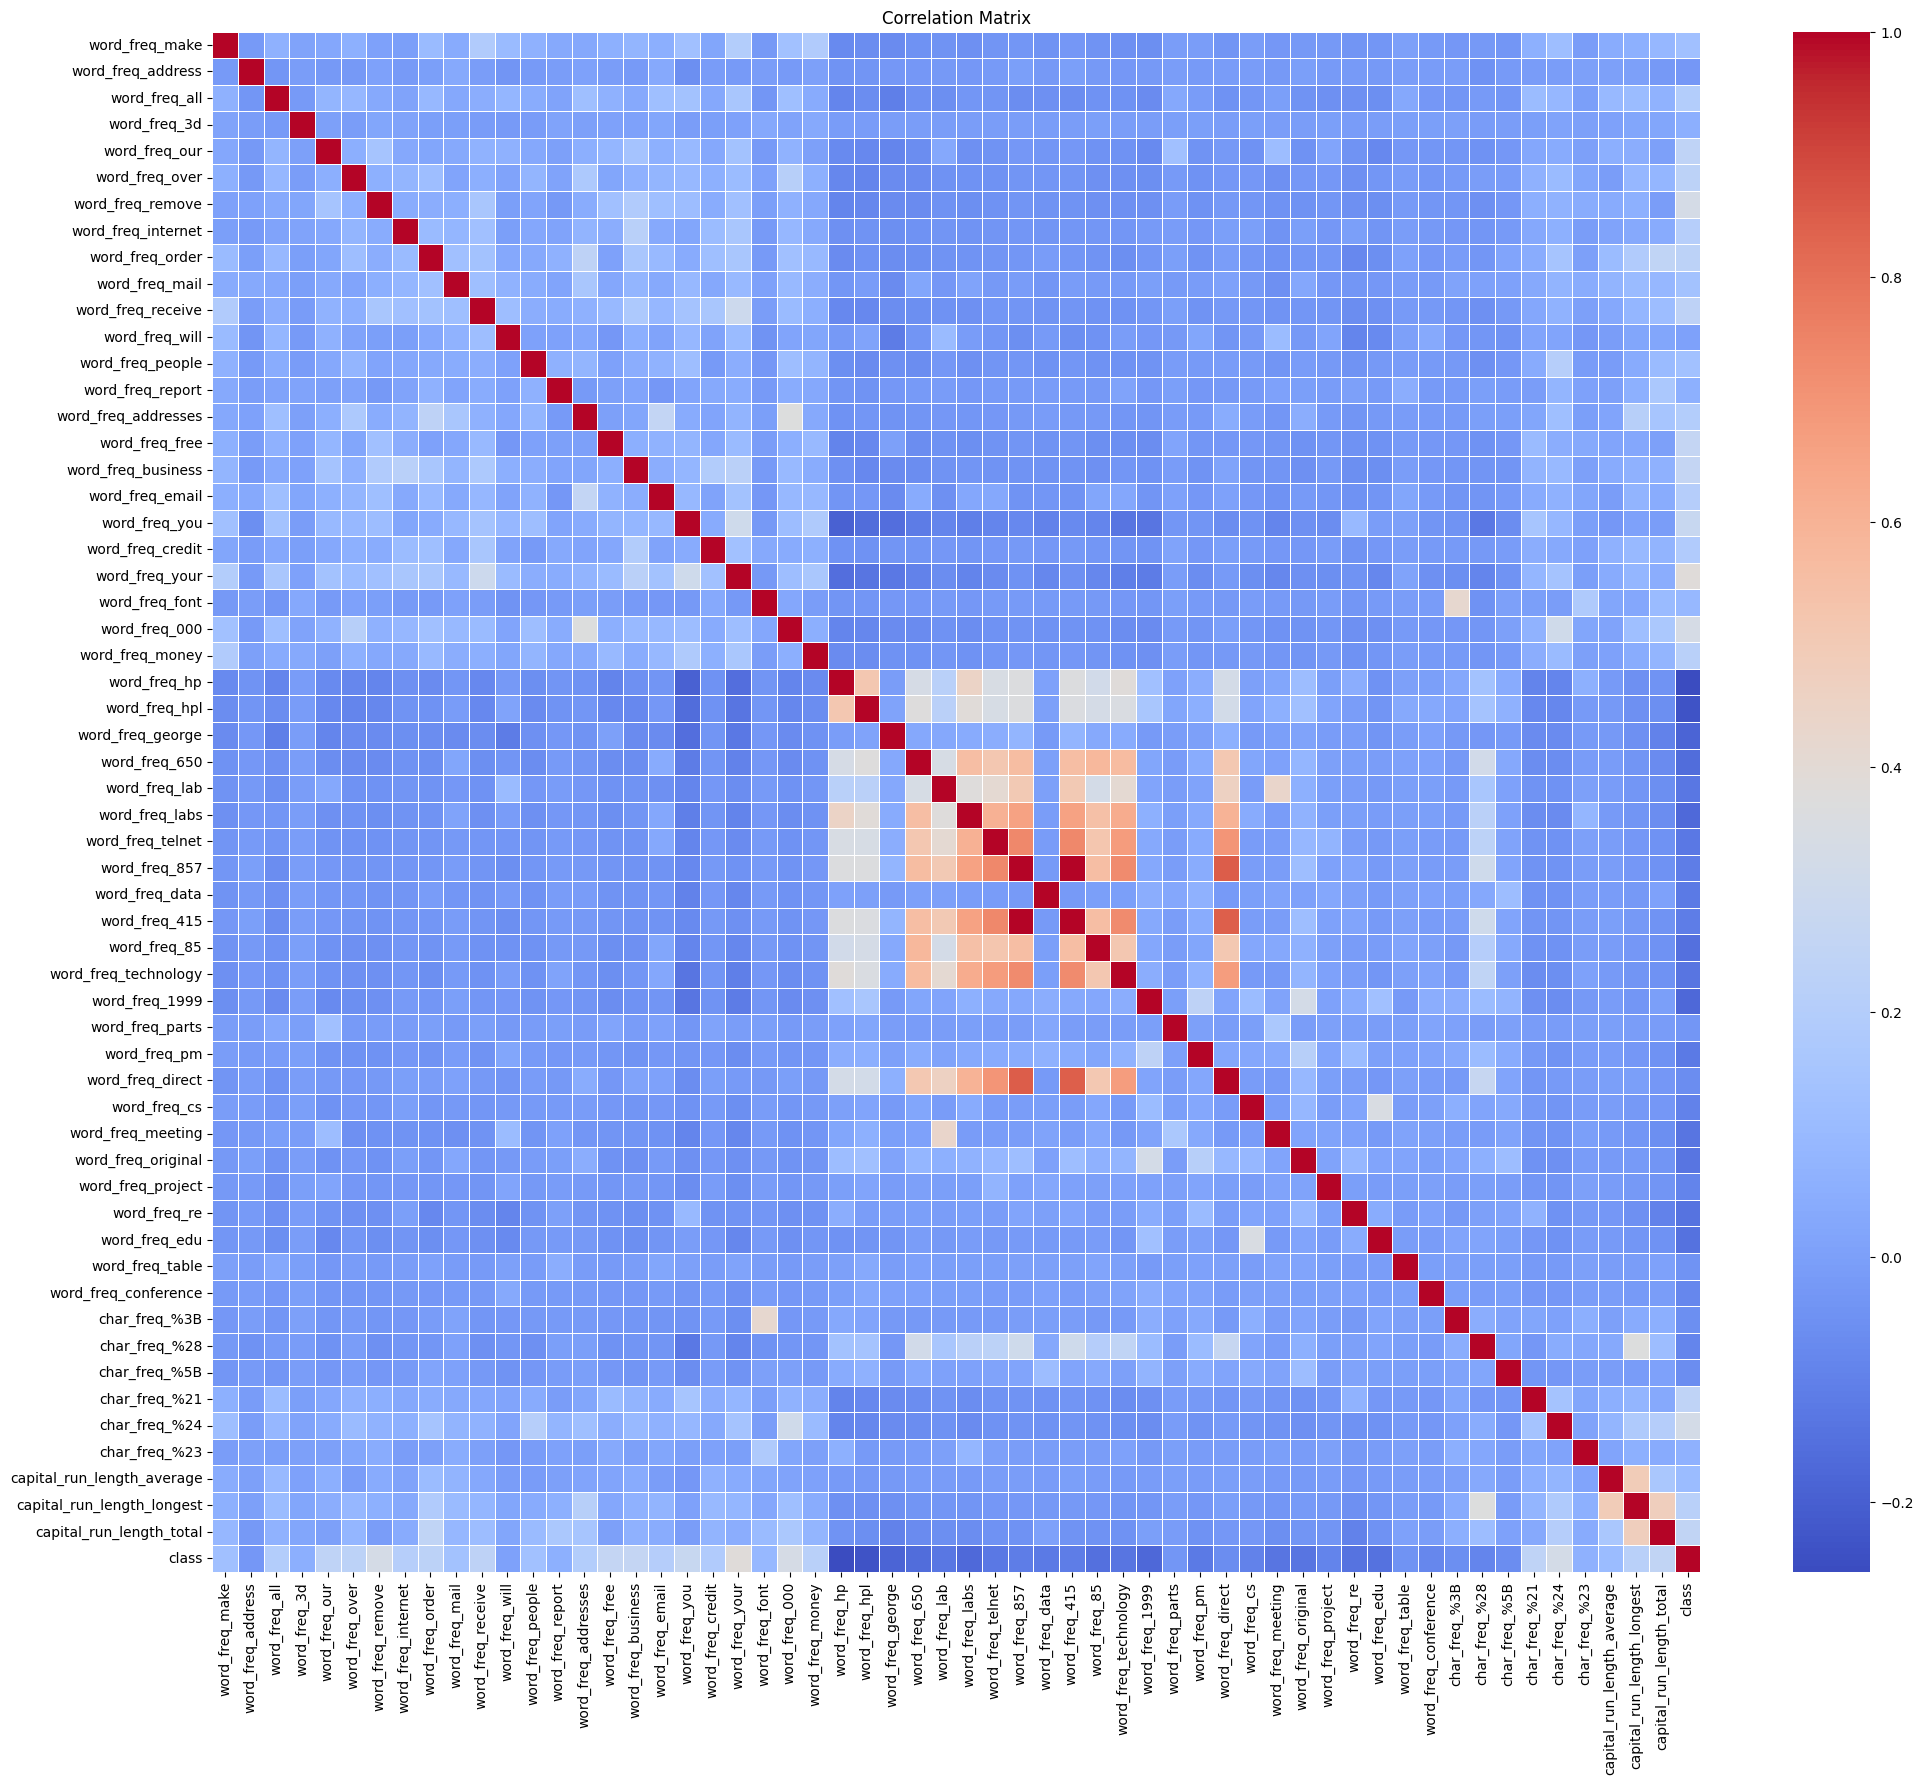

In [9]:

plt.figure(figsize=(24, 20))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns = X.columns,
    index = X.index
)
X_scaled

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,-0.342434,0.330885,0.712859,-0.0469,0.011565,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,-0.158453,-0.514307,-0.155198,0.624007,-0.308355,-0.103048,-0.045247,0.045298,-0.008724
1,0.345359,0.051909,0.435130,-0.0469,-0.256117,0.672399,0.244743,-0.088010,-0.323302,1.086711,...,-0.111546,-0.158453,-0.026007,-0.155198,0.126203,0.423783,0.008763,-0.002443,0.250563,1.228324
2,-0.145921,-0.165072,0.851723,-0.0469,1.364846,0.343685,0.193644,0.036670,1.974017,0.016422,...,-0.111546,-0.117376,0.014684,-0.155198,0.008496,0.440053,-0.079754,0.145921,2.221106,3.258733
3,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.111546,-0.158453,-0.007511,-0.155198,-0.161934,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222
4,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.111546,-0.158453,-0.014910,-0.155198,-0.164387,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.672880,-0.165072,0.673183,-0.0469,-0.464314,0.781971,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,-0.158453,0.343917,-0.155198,-0.329912,-0.308355,-0.103048,-0.127640,-0.252336,-0.322110
4597,-0.342434,-0.165072,-0.556761,-0.0469,-0.464314,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,-0.158453,-0.514307,-0.155198,0.102907,-0.308355,-0.103048,-0.114623,-0.247205,-0.444165
4598,0.640128,-0.165072,0.038373,-0.0469,-0.464314,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,0.260533,2.141746,-0.155198,-0.329912,-0.308355,-0.103048,-0.119382,-0.236941,-0.272628
4599,2.801763,-0.165072,-0.556761,-0.0469,0.011565,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.111546,-0.158453,-0.303450,-0.155198,-0.329912,-0.308355,-0.103048,-0.127483,-0.242073,-0.338604


Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X_scaled, y, test_size=0.2, random_state=42, stratify=y,
)

In [12]:
X_train.shape

(3680, 57)

In [13]:
X_test.shape

(921, 57)

Baseline Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression
import time

start_time = time.time()
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
training_time = time.time() - start_time
training_time


0.030675411224365234

In [15]:
predictions = lr.predict(X_test)
predictions

array([1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,

In [16]:
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score,
confusion_matrix, classification_report, roc_auc_score,
roc_curve, average_precision_score
)

print("Accuracy: ",accuracy_score(y_test, predictions))
print("Precision: ", precision_score(y_test, predictions, average="weighted"))
print("Recall: ", recall_score(y_test, predictions))
print("F1 Score: ", f1_score(y_test, predictions))
print("Training Time: ", training_time)

Accuracy:  0.9294245385450597
Precision:  0.9292892911840629
Recall:  0.8980716253443526
F1 Score:  0.9093444909344491
Training Time:  0.030675411224365234


Tune Logistic Regression hyperparameters.

In [17]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_grid = {
    'C':[0.01,0.1,1,10,100],
    'penalty':['l1','l2'],
    'solver':['liblinear','saga']
}

search=GridSearchCV(estimator=LogisticRegression(max_iter=5000),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1)

search.fit(X_train, y_train)

print("best params", search.best_params_)
print("best CV acc", search.best_score_)
best_grid_model = search.best_estimator_

results_df = pd.DataFrame(search.cv_results_)
best_idx = search.best_index_
print("\nFold-wise accuracy for best parameters:")
print(results_df.loc[best_idx, [c for c in results_df.columns if
c.startswith('split')]])

C:\Users\mehan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mehan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


best params {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
best CV acc 0.9241847826086957

Fold-wise accuracy for best parameters:
split0_test_score    0.938859
split1_test_score    0.915761
split2_test_score    0.923913
split3_test_score    0.917120
split4_test_score    0.925272
Name: 9, dtype: float64


In [18]:
from scipy.stats import loguniform

param_dist = {
    'C':loguniform(1e-4, 1e2),
    'penalty':['l1','l2'],
    'solver':['liblinear','saga']
}

search = RandomizedSearchCV( estimator = lr,
                            param_distributions=param_dist,
                            n_iter=20,
                            cv=5,
                            scoring = 'accuracy',
                            random_state=42,
                            n_jobs=-1
                           )

search.fit(X_train, y_train)

print("best params", search.best_params_)
print("best CV acc", search.best_score_)
best_rand_model = search.best_estimator_

results_df = pd.DataFrame(search.cv_results_)
best_idx = search.best_index_
print("\nFold-wise accuracy for best parameters:")
print(results_df.loc[best_idx, [c for c in results_df.columns if
c.startswith('split')]])

best params {'C': np.float64(0.35849855803404745), 'penalty': 'l1', 'solver': 'liblinear'}
best CV acc 0.9239130434782608

Fold-wise accuracy for best parameters:
split0_test_score    0.937500
split1_test_score    0.914402
split2_test_score    0.923913
split3_test_score    0.915761
split4_test_score    0.927989
Name: 14, dtype: float64


C:\Users\mehan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\mehan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [19]:
predictions = best_grid_model.predict(X_test)
predictions

array([1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,

In [20]:
print("Accuracy: ",accuracy_score(y_test, predictions))
print("Precision: ", precision_score(y_test, predictions, average="weighted"))
print("Recall: ", recall_score(y_test, predictions))
print("F1 Score: ", f1_score(y_test, predictions))

Accuracy:  0.9294245385450597
Precision:  0.9292892911840629
Recall:  0.8980716253443526
F1 Score:  0.9093444909344491


SVM

In [21]:
from sklearn.svm import SVC

In [22]:
start_time = time.time()
linear_svc=SVC(kernel="linear")
linear_svc.fit(X_train, y_train)
train_time = time.time()-start_time

y_pred = linear_svc.predict(X_test)
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("Training Time: ", train_time)

Accuracy Score:  0.9305103148751357
F1 Score:  0.9106145251396648
Training Time:  0.48413515090942383


In [23]:
start_time = time.time()
poly_svc=SVC(kernel="poly")
poly_svc.fit(X_train, y_train)
train_time = time.time()-start_time

y_pred = poly_svc.predict(X_test)
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("Training Time: ", train_time)

Accuracy Score:  0.7795874049945711
F1 Score:  0.6219739292364991
Training Time:  0.483173131942749


In [24]:
start_time = time.time()
rbf_svc=SVC(kernel="rbf")
rbf_svc.fit(X_train, y_train)
train_time = time.time()-start_time

y_pred = rbf_svc.predict(X_test)
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("Training Time: ", train_time)

Accuracy Score:  0.9272529858849077
F1 Score:  0.9055007052186178
Training Time:  0.26671624183654785


In [25]:
start_time = time.time()
sigmoid_svc=SVC(kernel="sigmoid")
sigmoid_svc.fit(X_train, y_train)
train_time = time.time()-start_time

y_pred = sigmoid_svc.predict(X_test)
print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))
print("Training Time: ", train_time)

Accuracy Score:  0.8838219326818675
F1 Score:  0.8524137931034482
Training Time:  0.2410738468170166


Hyperparameter tuning

In [26]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

param_grid = {
    'C':[0.1,1,10, 100],
    'kernel':['poly','rbf','sigmoid'],
    'gamma':['scale','auto'],
    'degree':[2,3,4]
}

search=GridSearchCV(estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1)

search.fit(X_train, y_train)

print("best params", search.best_params_)
print("best CV acc", search.best_score_)
best_grid_model = search.best_estimator_

results_df = pd.DataFrame(search.cv_results_)
best_idx = search.best_index_
print("\nFold-wise accuracy for best parameters:")
print(results_df.loc[best_idx, [c for c in results_df.columns if
c.startswith('split')]])

best params {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
best CV acc 0.9339673913043478

Fold-wise accuracy for best parameters:
split0_test_score    0.945652
split1_test_score    0.933424
split2_test_score    0.927989
split3_test_score    0.922554
split4_test_score    0.940217
Name: 19, dtype: float64


In [27]:
from scipy.stats import loguniform

param_dist = {
    'C':loguniform(1e-4, 1e2),
    'kernel':['poly','rbf','sigmoid'],
    'gamma':['scale','auto'],
    'degree':[2,3,4]
}

search = RandomizedSearchCV( estimator = SVC(),
                            param_distributions=param_dist,
                            n_iter=20,
                            cv=5,
                            scoring = 'accuracy',
                            random_state=42,
                            n_jobs=-1
                           )

search.fit(X_train, y_train)

print("best params", search.best_params_)
print("best CV acc", search.best_score_)
best_rand_model = search.best_estimator_

results_df = pd.DataFrame(search.cv_results_)
best_idx = search.best_index_
print("\nFold-wise accuracy for best parameters:")
print(results_df.loc[best_idx, [c for c in results_df.columns if
c.startswith('split')]])

best params {'C': np.float64(4.765911808680843), 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
best CV acc 0.9347826086956521

Fold-wise accuracy for best parameters:
split0_test_score    0.944293
split1_test_score    0.936141
split2_test_score    0.936141
split3_test_score    0.918478
split4_test_score    0.938859
Name: 1, dtype: float64


5 Fold Cross Validation

In [28]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(LogisticRegression(max_iter=5000), X_scaled, y, cv=5, scoring='accuracy')
print("Fold Accuracies:", scores)
print("Average Accuracy:", scores.mean())

Fold Accuracies: [0.92073833 0.92826087 0.9326087  0.94673913 0.83369565]
Average Accuracy: 0.9124085351461076


In [29]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(SVC(), X_scaled, y, cv=5, scoring='accuracy')
print("Fold Accuracies:", scores)
print("Average Accuracy:", scores.mean())

Fold Accuracies: [0.6558089  0.73152174 0.69891304 0.72934783 0.70978261]
Average Accuracy: 0.7050748241514422
